In [24]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import random

sys.path.append('../../')

from src.piece_functions import helix,cast_and_surge,persistent_random_walk,straight_line,generate_random_trajectory
from src.io import save_dataframe

Text(0.5, 0.92, 'cast and surge')

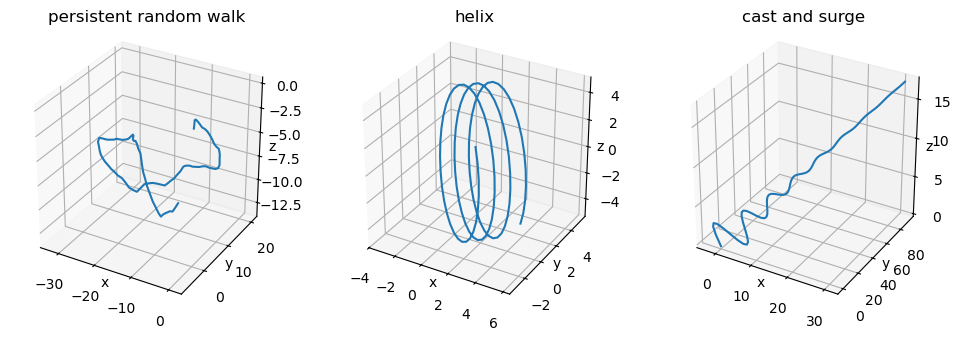

In [2]:
n_steps = 100
A = 1.
B = 1.
w = 0.01
step_size=1
#x, y, z = periodic_behavior_3d([0,0,0], n_steps, A=A, B=B, w=w, dt=step_size)
#x,y,z = cast_and_surge_3d([0,0,0],60,A0=5,decay=0.05,freq=0.5)

fig,ax = plt.subplots(ncols=3, figsize=(12,4),subplot_kw={'projection':'3d'})

x,y,z = persistent_random_walk([0.,0.,0.],n_steps=n_steps,turn_std=np.pi/10)
ax[0].plot(x,y,z)

x,y,z = helix([0.,0.,0.],n_steps=n_steps)
ax[1].plot(x,y,z)

x,y,z = cast_and_surge([0.,0.,0.],n_steps=n_steps)
ax[2].plot(x,y,z)

for i in range(3):
    ax[i].set_xlabel('x',labelpad=-15)
    ax[i].set_ylabel('y',labelpad=-15)
    ax[i].set_zlabel('z',labelpad=-15)
    #ax[i].set_xticklabels([])
    #ax[i].set_yticklabels([])
    #ax[i].set_zticklabels([])
    ax[i].grid(True)
    ax[i].set_box_aspect([1, 1, 1])
ax[0].set_title('persistent random walk')
ax[1].set_title('helix')
ax[2].set_title('cast and surge')

#fig.savefig('stereotypes.svg')

In [38]:
ttot = 2000
mvt_types = ['straight','persistent_random_walk','helix','persistent_random_walk','cast_and_surge']
mvt_args = {'straight':{'n_steps':100},'helix':{'radius':5,'pitch':5.},'cast_and_surge':{'A0':10,'decay':0.025},'persistent_random_walk':{'turn_std':np.pi/5}}
trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                step_size=1.,
                                                mvt_types = mvt_types,
                                                mvt_args=mvt_args)

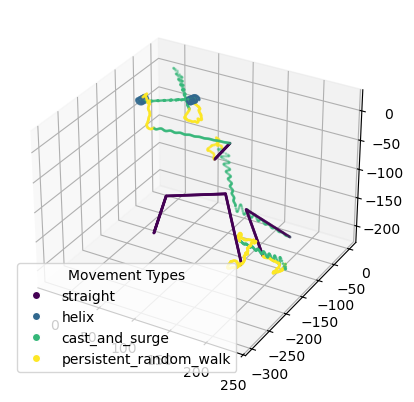

In [40]:
cmap = colormaps['viridis']
clr_dict ={'straight':cmap(0.),'helix':cmap(0.333),'cast_and_surge':cmap(0.666),'persistent_random_walk':cmap(1.)}
color_code = np.array([clr_dict[mv] for mv in move_names])
fig,ax = plt.subplots(subplot_kw={'projection':'3d'})
ax.scatter(trj[:,0],trj[:,1],trj[:,2],c=color_code,s=1)


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=key,
           markerfacecolor=color, markersize=6)
    for key, color in clr_dict.items()
]

ax.legend(handles=legend_elements, title="Movement Types")
fig.savefig('trajectory_example.svg',bbox_inches='tight')

In [ ]:
A = 0.1
ttot = 1000
nsample = 100
data_array = np.zeros((nsample,ttot,3),dtype=float)



In [29]:
A = 0.1
ttot = 1000
nsample = 100
data_array = np.zeros((nsample,ttot,3),dtype=float)
move_names_list = []
for i in range(data_array.shape[0]):
    rdxyz = np.array([np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A]).T


    data_array[i], move_names = generate_random_trajectory_3d(total_steps = ttot,
                                                                step_size=1.)
    
    
    move_names_list.append(move_names)

NameError: name 'generate_random_trajectory_3d' is not defined

In [4]:

# Assuming data_array has shape (1000, 1000, 3)
n_traj, n_frames, _ = data_array.shape

# Create flattened arrays
flat_xyz = data_array.reshape(-1, 3)
labels = np.repeat(np.arange(n_traj), n_frames)
frames = np.tile(np.arange(n_frames), n_traj)
flat_move_names = [item for sublist in move_names_list for item in sublist]

# Assemble into DataFrame
df = pd.DataFrame(flat_xyz, columns=['x', 'y', 'z'])
df['label'] = labels
df['frame'] = frames
df['move_type'] = flat_move_names


In [5]:
df.head()
color_dict = {"straight":0.,"cast_and_surge":1.}

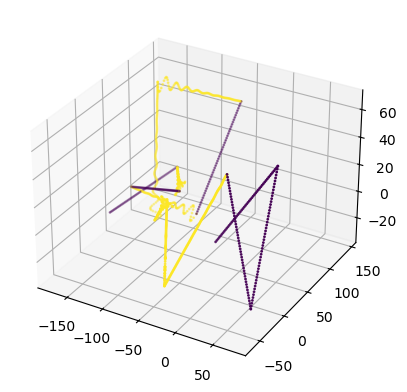

In [6]:
Ttot = 1000

color = np.zeros(Ttot,dtype=float)
for i in range(color.shape[0]):
    color[i] = color_dict[df['move_type'][i]]

ax = plt.subplot(projection='3d')
ax.scatter(df['x'][:Ttot],df['y'][:Ttot],df['z'][:Ttot],s=1.,c=color)#,marker='o')
plt.show()

In [7]:
#save_dataframe(df,"raw/cast_and_surge_and_straight.parquet")

In [7]:
df.groupby('label').size().value_counts()


1000    100
Name: count, dtype: int64

In [9]:
def canonicalize_trajectory(coords, *, return_rotation=False, tol=1e-12):
    """
    Rotate `coords` (K×3) into a unique canonical frame.
    Any rigid-body rotation + translation of the same trajectory
    maps to the *identical* output.

    Algorithm
    ---------
    1.  centre at the centroid
    2.  PCA → eigenvectors V (columns)
    3.  for each axis j:                       # sign disambiguation
        m3 = Σ (x_j')³   (third central moment)
        if |m3| < tol use   Σ x_j'² x_{j+1}'
        flip V[:,j] if m3 < 0
    4.  make the basis right-handed (det = +1)
    5.  rotated = centred @ V

    Returns
    -------
    canon : (K,3)  canonical coordinates (centroid at the origin)
    R      : (3,3) rotation matrix  (only if `return_rotation=True`)
    """

    X   = np.asarray(coords, dtype=float)
    C   = X - X.mean(axis=0)               # 1
    _,  _, Vt = np.linalg.svd(C, full_matrices=False)
    V   = Vt.T                             # 2

    Y   = C @ V                            # projections for moments
    for j in range(3):                     # 3
        m3 = (Y[:, j] ** 3).sum()
        if abs(m3) < tol:                  # nearly symmetric
            k = (j + 1) % 3
            m3 = (Y[:, j]**2 * Y[:, k]).sum()
        if m3 < 0:
            V[:, j] *= -1
            Y[:, j] *= -1

    if np.linalg.det(V) < 0:               # 4
        V[:, 2] *= -1
        Y[:, 2] *= -1

    canon = Y                               # 5
    ## Step 6: chiral disambiguation via lexicographic minimization
    mirrors = np.array([
        [ 1,  1,  1],
        [-1,  1,  1],
        [ 1, -1,  1],
        [ 1,  1, -1],
        [-1, -1,  1],
        [-1,  1, -1],
        [ 1, -1, -1],
        [-1, -1, -1]
    ])  # shape (8, 3)

    mirrored = np.einsum('ij,kj->kij', canon, mirrors)  #µ shape (8, K, 3)

    flat = mirrored.reshape(8, -1)  # shape (8, 3K)
    best_index = np.lexsort(flat.T)[0]
    canon = mirrored[best_index]

    return (canon, V) if return_rotation else canon

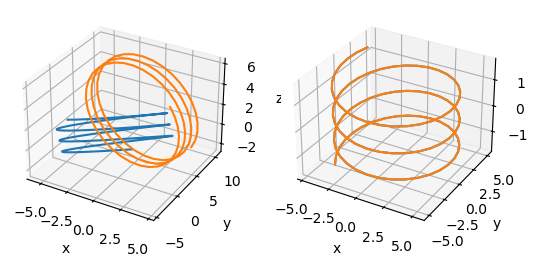

In [11]:
x1,y1,z1 =  helix(start = np.array([0.,0.,0.]), n_steps=100, radius=5, pitch=1.0, clockwise=True, step=1.0)
x2,y2,z2 =  helix(start = np.array([1.,5.,3.]), n_steps=100, radius=5, pitch=-1.0, clockwise=False, step=1.0)
fig,ax = plt.subplots(ncols= 2,subplot_kw={"projection":'3d'})
ax[0].plot(x1,y1,z1)
ax[0].plot(x2,y2,z2)

xyz1 = canonicalize_trajectory(np.array([x1,y1,z1]).T)
xyz2 = canonicalize_trajectory(np.array([x2,y2,z2]).T)

ax[1].plot(xyz1[:,0],xyz1[:,1],xyz1[:,2])
ax[1].plot(xyz2[:,0],xyz2[:,1],xyz2[:,2])
for i in range(2):
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('y')
    ax[i].set_zlabel('z')
fig.savefig('helix_disambiguation.pdf',bbox_inches='tight')